# Qwen2.5-7B (4-bit MLX) vs. Qwen2.5-3B on FinQA — brief analysis

200 validation questions, same prompt, temperature 0.7, 512 max tokens, `percent_scale` matching, tolerance 0.01.
- **3B**: `validation-200q`, bf16 on `transformers`, N=4 and N=8.
- **7B**: `validation-200q-7b`, 4-bit `mlx-community/Qwen2.5-7B-Instruct-4bit`, N=1 and N=4.

Backend and quantization differ between the two models, so the comparison mixes model size with those changes. Reads result files only.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

SURFACE, INK, MUTED, GRID = "#fcfcfb", "#0b0b0b", "#898781", "#e1e0d9"
BLUE, GREEN, AMBER, RED = "#2a78d6", "#1baf7a", "#eda100", "#e34948"

runs = []
for group, label in (("validation-200q", "3B"), ("validation-200q-7b", "7B (4-bit)")):
    for path in sorted((Path("../results") / group).glob("*.json")):
        e = json.load(open(path))
        d = e["metrics"]["diagnostics"]
        runs.append({
            "model": label, "N": e["num_samples"],
            "accuracy": e["metrics"]["accuracy"],
            "strict": d["accuracy_strict"],
            "pass@N": d["pass_at_n"],
            "single-sample": d["sample_accuracy"],
            "tokens/question": e["metrics"]["average_tokens"],
            "latency (s)": e["metrics"]["average_latency"],
            "examples": e["examples"], "q_tags": d["question_tags"],
        })
df = pd.DataFrame(runs)
df.drop(columns=["examples", "q_tags"]).round(3)

,model,N,accuracy,strict,pass@N,single-sample,tokens/question,latency (s)
0,3B,4,0.615,0.290,0.710,0.566,5846.700,77.303
1,3B,8,0.615,0.285,0.735,0.542,11672.055,152.668
2,7B (4-bit),1,0.655,0.375,0.655,0.655,1430.310,13.185
3,7B (4-bit),4,0.705,0.420,0.770,0.662,5705.990,52.083


## Accuracy, pass@N and compute

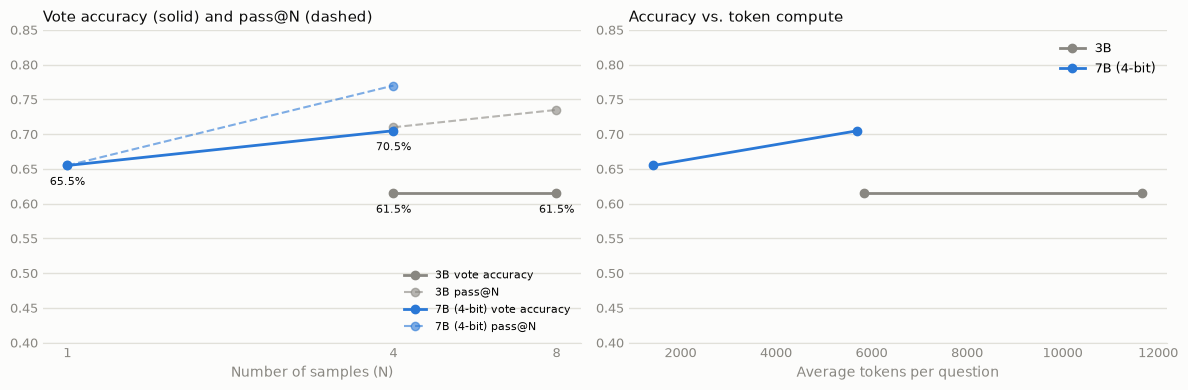

In [2]:
def style(ax):
    ax.set_facecolor(SURFACE)
    for s in ("top", "right", "left"):
        ax.spines[s].set_visible(False)
    ax.spines["bottom"].set_color(GRID)
    ax.tick_params(colors=MUTED, length=0, labelsize=9)
    ax.grid(axis="y", color=GRID, linewidth=1)
    ax.set_axisbelow(True)

COLOURS = {"3B": MUTED, "7B (4-bit)": BLUE}
fig, (a, b) = plt.subplots(1, 2, figsize=(12, 4), facecolor=SURFACE)
for model, g in df.groupby("model"):
    g = g.sort_values("N")
    a.plot(g["N"], g["accuracy"], color=COLOURS[model], marker="o", linewidth=2, label=f"{model} vote accuracy")
    a.plot(g["N"], g["pass@N"], color=COLOURS[model], marker="o", linestyle="--", alpha=0.6, label=f"{model} pass@N")
    for _, r in g.iterrows():
        a.annotate(f"{r['accuracy']:.1%}", (r["N"], r["accuracy"]), xytext=(0, -14), textcoords="offset points", ha="center", fontsize=8, color=INK)
    b.plot(g["tokens/question"], g["accuracy"], color=COLOURS[model], marker="o", linewidth=2, label=model)
a.set_xscale("log", base=2); a.set_xticks([1, 4, 8]); a.set_xticklabels([1, 4, 8])
a.set_xlabel("Number of samples (N)", color=MUTED); a.set_ylim(0.4, 0.85)
a.set_title("Vote accuracy (solid) and pass@N (dashed)", loc="left", fontsize=11, color=INK)
a.legend(frameon=False, fontsize=8, loc="lower right")
b.set_xlabel("Average tokens per question", color=MUTED); b.set_ylim(0.4, 0.85)
b.set_title("Accuracy vs. token compute", loc="left", fontsize=11, color=INK)
b.legend(frameon=False, fontsize=9)
for ax in (a, b):
    style(ax)
plt.tight_layout(); plt.show()

## Where the questions end up (after the vote)

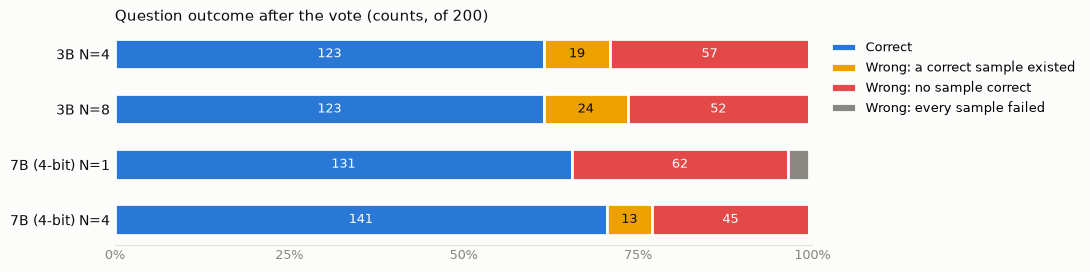

,vote_correct,vote_lost,none_correct,all_failed
3B N=4,123,19,57,0
3B N=8,123,24,52,0
7B (4-bit) N=1,131,0,62,6
7B (4-bit) N=4,141,13,45,0


In [3]:
GROUPS = [("vote_correct", "Correct", BLUE), ("vote_lost", "Wrong: a correct sample existed", AMBER),
          ("none_correct", "Wrong: no sample correct", RED), ("all_failed", "Wrong: every sample failed", MUTED)]
rows = {}
for r in runs:
    t = dict(r["q_tags"])
    t["vote_lost"] = t.get("vote_lost", 0) + t.pop("tie_lost", 0)
    rows[f"{r['model']} N={r['N']}"] = {k: t.get(k, 0) for k, _, _ in GROUPS}
counts = pd.DataFrame(rows).T
fig, ax = plt.subplots(figsize=(9, 2.8), facecolor=SURFACE)
left = pd.Series(0.0, index=counts.index)
for key, label, colour in GROUPS:
    share = counts[key] / 200
    ax.barh(counts.index, share, left=left, color=colour, edgecolor=SURFACE, linewidth=2, height=0.55, label=label)
    for y, (name, s) in enumerate(share.items()):
        if s >= 0.05:
            ax.text(left[name] + s / 2, y, int(counts.loc[name, key]), ha="center", va="center", fontsize=9, color=INK if colour == AMBER else "white")
    left += share
ax.set_xlim(0, 1); ax.invert_yaxis(); style(ax); ax.grid(False)
ax.set_xticks([0, .25, .5, .75, 1]); ax.set_xticklabels(["0%", "25%", "50%", "75%", "100%"])
ax.tick_params(axis="y", labelsize=10, labelcolor=INK)
ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1), frameon=False, fontsize=9)
ax.set_title("Question outcome after the vote (counts, of 200)", loc="left", fontsize=11, color=INK)
plt.show()
counts

## Paired comparison: same 200 questions, 3B vs. 7B

In [4]:
def correct_map(model, n):
    r = next(r for r in runs if r["model"] == model and r["N"] == n)
    return {ex["question_id"]: ex["correct"] for ex in r["examples"]}

pairs = [(("3B", 4), ("7B (4-bit)", 4)), (("3B", 4), ("7B (4-bit)", 1))]
out = []
for (m1, n1), (m2, n2) in pairs:
    a, b = correct_map(m1, n1), correct_map(m2, n2)
    gained = sum(b[q] and not a[q] for q in a)
    lost = sum(a[q] and not b[q] for q in a)
    out.append({"baseline": f"{m1} N={n1}", "compared": f"{m2} N={n2}", "fixed by compared": gained,
                "broken by compared": lost, "net": gained - lost})
pd.DataFrame(out)

,baseline,compared,fixed by compared,broken by compared,net
0,3B N=4,7B (4-bit) N=4,30,12,18
1,3B N=4,7B (4-bit) N=1,23,15,8


## Takeaways

- **7B beats 3B at the same compute.** 7B N=4 reaches 70.5% (141/200) against 61.5% for 3B N=4, +9 points, with about the same tokens per question (5.7k vs 5.8k). In the paired comparison 7B fixed 30 questions the 3B got wrong and broke 12 (net +18). Even 7B at N=1 (65.5%) beats 3B at N=4 and N=8, at roughly a quarter of the tokens.
- **Scaling N helps the 7B model, unlike the 3B.** 7B goes 65.5% to 70.5% from N=1 to N=4. The 3B showed no change from N=4 to N=8, though there is no 3B N=1 run to compare against.
- **Selection gap is smaller.** 7B N=4 has pass@N of 77.0% against 70.5% voted (13 questions where a correct sample lost), compared with 24 such questions for 3B at N=8. A better selector has less to recover, and the remaining failures are mostly questions with no correct sample (45 of 200).
- **Single-sample accuracy** rose from about 55% (3B) to about 66% (7B), which is the main source of the gain.
- **Caveats:** 200 questions gives roughly ±3 points of noise per accuracy figure, so the 9-point gap over 3B is solid but the 5-point N=1 to N=4 gain is within about two standard errors. The 7B runs use 4-bit MLX and the 3B runs use bf16 on `transformers`, so backend and quantization are confounded with model size.